# 05 EfficientNetB0 Fine Transfer Learning

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fgram-devAI/deepl-cifar100-image-analysis/blob/main/notebooks/05_efficientnet_b0_fine_transfer_learning.ipynb)


## 1. Setup

Install missing dependencies on demand, then import the scientific Python stack used by the notebook. This mirrors the project notebooks: the notebook should run from Colab without cloning or changing into the repository.

In [1]:
# Install dependencies on demand for a fresh Colab environment. Each install
# is gated on a successful import so reruns are no-ops.
import importlib
import subprocess
import sys


def ensure(package: str, import_name: str | None = None) -> None:
    import_name = import_name or package
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


ensure("datasets")
ensure("scikit-learn", "sklearn")


In [2]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())


TensorFlow: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load CIFAR-100

Pull both CIFAR-100 splits from Hugging Face and materialise them as NumPy arrays. Images stay as `uint8` here; model pipelines normalise or rescale them explicitly later.

In [3]:
ds = load_dataset("uoft-cs/cifar100")


def split_to_arrays(split):
    images = np.stack([
        np.asarray(img.convert("RGB"), dtype=np.uint8) for img in split["img"]
    ])
    fine = np.asarray(split["fine_label"], dtype=np.int64)
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, fine, coarse


train_images, train_fine, train_coarse = split_to_arrays(ds["train"])
test_images, test_fine, test_coarse = split_to_arrays(ds["test"])

fine_names = ds["train"].features["fine_label"].names
coarse_names = ds["train"].features["coarse_label"].names
FINE_LABELS = fine_names
COARSE_LABELS = coarse_names
FINE_ID = {name: i for i, name in enumerate(fine_names)}
COARSE_ID = {name: i for i, name in enumerate(coarse_names)}

print("train_images", train_images.shape, train_images.dtype)
print("test_images", test_images.shape, test_images.dtype)
print("fine classes", len(fine_names), "coarse classes", len(coarse_names))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train_images (50000, 32, 32, 3) uint8
test_images (10000, 32, 32, 3) uint8
fine classes 100 coarse classes 20


# EfficientNetB0 Model Definition

# Define Config: EfficientNetB0 Frozen Backbone

In [4]:
import yaml

config_str = """
architecture: efficientnet_b0
run_name: efficientnet_b0_fine_frozen_in128_ep30
seed: 42

task:
  type: multiclass
  label_level: fine          # <-- 100 classes (was: coarse / 20)

validation:
  fraction: 0.1

class_imbalance:
  strategy: none             # CIFAR-100 is balanced (500/class)

batch_size: 64
shuffle_buffer: 4096
dropout: 0.4                 # a touch higher for the harder 100-class task
epochs: 30                  # was 10
optimizer: adam
learning_rate: 1e-3         # ok while the backbone is FROZEN

freeze_backbone: true       # this config keeps it frozen (the "better baseline")
input_size: 128             # was 96; try 160 if the GPU allows (drop batch_size to 32)

augmentation:               # exact keys expected by models/augmentation.py
  enabled: true             # REQUIRED — without this the whole block is ignored
  horizontal_flip: true
  translation: 0.1
  zoom: 0.1
  rotation: 0.05
  contrast: 0.1

early_stopping:
  monitor: val_loss
  patience: 8               # was 5

output_dir: results/efficientnet_b0_fine_frozen
save_weights: true
subset_size: null
"""

config = yaml.safe_load(config_str)
print(config)

{'architecture': 'efficientnet_b0', 'run_name': 'efficientnet_b0_fine_frozen_in128_ep30', 'seed': 42, 'task': {'type': 'multiclass', 'label_level': 'fine'}, 'validation': {'fraction': 0.1}, 'class_imbalance': {'strategy': 'none'}, 'batch_size': 64, 'shuffle_buffer': 4096, 'dropout': 0.4, 'epochs': 30, 'optimizer': 'adam', 'learning_rate': '1e-3', 'freeze_backbone': True, 'input_size': 128, 'augmentation': {'enabled': True, 'horizontal_flip': True, 'translation': 0.1, 'zoom': 0.1, 'rotation': 0.05, 'contrast': 0.1}, 'early_stopping': {'monitor': 'val_loss', 'patience': 8}, 'output_dir': 'results/efficientnet_b0_fine_frozen', 'save_weights': True, 'subset_size': None}


# Verify Model and Config Setup

# Install Keras and Set Environment Variable

In [5]:
ensure("tf_keras")
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"


# Define EfficientNetB0 Fine-Tuning Model


In [6]:

"""EfficientNetB0 transfer-learning model for CIFAR-100 multiclass tasks."""

import tensorflow as tf

keras = tf.keras
layers = tf.keras.layers


def build_augmentation(config: dict | None):
    if config is None or not config.get("enabled", False):
        return None
    aug_layers = []
    if config.get("horizontal_flip", False):
        aug_layers.append(layers.RandomFlip("horizontal"))
    if config.get("translation", 0.0) > 0:
        t = float(config["translation"])
        aug_layers.append(layers.RandomTranslation(t, t))
    if config.get("zoom", 0.0) > 0:
        aug_layers.append(layers.RandomZoom(float(config["zoom"])))
    if config.get("rotation", 0.0) > 0:
        aug_layers.append(layers.RandomRotation(float(config["rotation"])))
    if config.get("contrast", 0.0) > 0:
        aug_layers.append(layers.RandomContrast(float(config["contrast"])))
    return keras.Sequential(aug_layers, name="augmentation")

# EfficientNetB0 backbone has 237 layers total, grouped into 7 MBConv blocks
# (block1..block7) plus a stem and a top. Layer-index where each block starts
# (measured at input_size=128; stable across input sizes since it's topology,
# not shape, that determines block boundaries):
#   stem -> 3   block1 -> 7   block2 -> 17   block3 -> 46   block4 -> 75
#   block5 -> 119   block6 -> 162   block7 -> 221   top -> 234   (237 total)
# So unfreeze_from="block6" leaves the first ~68% of the network frozen and
# trains only the last ~75 layers (block6, block7, top) — usually the best
# accuracy/stability tradeoff for a single-stage fine-tune.


def build_efficientnet_b0(
    input_shape: tuple[int, int, int] = (32, 32, 3),
    num_classes: int = 100,
    dropout: float = 0.4,
    freeze_backbone: bool = True,
    unfreeze_from: str | None = None,   # None | "all" | "block5" | "block6" | "block7" | "top"
    freeze_bn: bool = True,             # keep BatchNorm stats frozen (recommended)
    input_size: int = 128,
    augmentation: dict | None = None,
) -> keras.Model:
    """EfficientNetB0 classifier for CIFAR-100.

    32x32 -> resize(input_size) -> rescale to [0,255] (EfficientNet has its own
    internal normalization) -> ImageNet backbone -> dropout + softmax head.
    Returned uncompiled.

    Backbone freezing modes:
      - freeze_backbone=True: everything frozen (fastest, weakest).
      - freeze_backbone=False, unfreeze_from=None or "all": everything
        trainable (strongest ceiling, but riskiest single-stage — needs a
        very low learning_rate, e.g. 1e-5).
      - freeze_backbone=False, unfreeze_from="block6" (etc.): only layers
        from that block onward are trainable; everything before it stays
        frozen. This is the recommended middle ground — adapts the
        high-level semantic features without disturbing low-level filters,
        and tolerates a higher learning_rate (~1e-4).

    freeze_bn=True additionally keeps every BatchNormalization layer frozen
    (non-trainable + inference-mode stats) even when its block is unfrozen.
    This avoids corrupting running mean/variance on small batches — almost
    always what you want when fine-tuning a pretrained backbone.
    """
    if num_classes < 1:
        raise ValueError(f"num_classes must be >= 1; got {num_classes}")

    inputs = keras.Input(shape=input_shape, name="image")

    aug_layer = build_augmentation(augmentation)
    x = aug_layer(inputs) if aug_layer is not None else inputs

    x = layers.Resizing(input_size, input_size, interpolation="bilinear")(x)
    x = layers.Rescaling(255.0)(x)

    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_size, input_size, 3),
        pooling="avg",
    )

    if freeze_backbone:
        backbone.trainable = False
    else:
        backbone.trainable = True
        if unfreeze_from not in (None, "all"):
            # Freeze everything before `unfreeze_from`; train from there on.
            trainable = False
            for layer in backbone.layers:
                if layer.name.startswith(unfreeze_from):
                    trainable = True
                layer.trainable = trainable
        if freeze_bn:
            for layer in backbone.layers:
                if isinstance(layer, layers.BatchNormalization):
                    layer.trainable = False

    # Run in inference mode (training=False) whenever the backbone is fully
    # frozen, so BN uses its pretrained running stats rather than batch stats.
    backbone_is_fully_frozen = freeze_backbone
    x = backbone(x, training=False)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_b0")


In [8]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score as sk_f1, confusion_matrix as sk_cm,
)

AUGMENTATION_CFG = {
    "enabled": True,
    "horizontal_flip": True,
    "translation": 0.1,
    "zoom": 0.1,
    "rotation": 0.05,
    "contrast": 0.1,
}

# ── Run 1: frozen backbone ──────────────────────────────────────────────────
RUN1_DIR = Path("/content/efnetb0_fine_frozen")
RUN1_DIR.mkdir(parents=True, exist_ok=True)

if (RUN1_DIR / "history.json").exists() and (RUN1_DIR / "metrics.json").exists():
    print("Run 1 (frozen backbone) cached — skipping training.")
else:
    X_tr, X_val, y_tr, y_val = train_test_split(
        train_images, train_fine,
        test_size=0.10, stratify=train_fine, random_state=SEED,
    )
    X_tr  = X_tr.astype("float32")  / 255.0
    X_val = X_val.astype("float32") / 255.0

    m1 = build_efficientnet_b0(
        input_shape=(32, 32, 3),
        num_classes=100,
        dropout=0.4,
        freeze_backbone=True,
        input_size=128,
        augmentation=AUGMENTATION_CFG,
    )
    m1.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    _h1 = m1.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=30, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True)],
        verbose=2,
    )
    test_f = test_images.astype("float32") / 255.0
    y_pred1 = m1.predict(test_f, batch_size=64, verbose=0).argmax(axis=1)
    _, acc1 = m1.evaluate(test_f, test_fine, verbose=0)
    m1.save_weights(str(RUN1_DIR / "weights.weights.h5"))
    with open(RUN1_DIR / "history.json", "w") as fh:
        json.dump({k: [float(v) for v in vals] for k, vals in _h1.history.items()}, fh, indent=2)
    with open(RUN1_DIR / "metrics.json", "w") as fh:
        json.dump({
            "accuracy":         float(acc1),
            "macro_precision":  float(precision_score(test_fine, y_pred1, average="macro", zero_division=0)),
            "macro_recall":     float(recall_score(test_fine, y_pred1, average="macro", zero_division=0)),
            "macro_f1":         float(sk_f1(test_fine, y_pred1, average="macro", zero_division=0)),
            "weighted_f1":      float(sk_f1(test_fine, y_pred1, average="weighted", zero_division=0)),
            "confusion_matrix": sk_cm(test_fine, y_pred1).tolist(),
        }, fh, indent=2)
    print(f"Run 1 complete. Saved to {RUN1_DIR}")

Epoch 1/30
704/704 - 53s - 76ms/step - accuracy: 0.3773 - loss: 2.5552 - val_accuracy: 0.6272 - val_loss: 1.3925
Epoch 2/30
704/704 - 40s - 56ms/step - accuracy: 0.4895 - loss: 1.9332 - val_accuracy: 0.6508 - val_loss: 1.2483
Epoch 3/30
704/704 - 41s - 58ms/step - accuracy: 0.5183 - loss: 1.8060 - val_accuracy: 0.6672 - val_loss: 1.1832
Epoch 4/30
704/704 - 81s - 115ms/step - accuracy: 0.5286 - loss: 1.7547 - val_accuracy: 0.6734 - val_loss: 1.1550
Epoch 5/30
704/704 - 39s - 56ms/step - accuracy: 0.5354 - loss: 1.7136 - val_accuracy: 0.6796 - val_loss: 1.1378
Epoch 6/30
704/704 - 39s - 56ms/step - accuracy: 0.5487 - loss: 1.6735 - val_accuracy: 0.6810 - val_loss: 1.1289
Epoch 7/30
704/704 - 39s - 55ms/step - accuracy: 0.5502 - loss: 1.6571 - val_accuracy: 0.6830 - val_loss: 1.1186
Epoch 8/30
704/704 - 39s - 55ms/step - accuracy: 0.5530 - loss: 1.6434 - val_accuracy: 0.6864 - val_loss: 1.1100
Epoch 9/30
704/704 - 42s - 59ms/step - accuracy: 0.5522 - loss: 1.6329 - val_accuracy: 0.6886 -

# Optional Source Training: EfficientNetB0 Frozen Backbone


The duplicate frozen-backbone source training command was removed. The result-inspection cells below keep the imported run outputs and can be rerun when the matching local artifacts are present.


# Attempt Train Model: EfficientNetB0 Unfreeze Block6 (Error)

The old unfreeze-block6 command used a notebook-generated config path and is intentionally not executed here. This section preserves the imported unfreeze-block6 results and diagnostics.


# Train Model: EfficientNetB0 Unfreeze Block6 (Run 2)

In [9]:
# ── Run 2: unfreeze block6 ─────────────────────────────────────────────────
RUN2_DIR = Path("/content/efnetb0_fine_unfreeze_block6")
RUN2_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS2 = RUN2_DIR / "weights.weights.h5"

# Build model first so it is always available for downstream prediction cells.
m2 = build_efficientnet_b0(
    input_shape=(32, 32, 3),
    num_classes=100,
    dropout=0.4,
    freeze_backbone=False,
    unfreeze_from="block6",
    freeze_bn=True,
    input_size=128,
    augmentation=AUGMENTATION_CFG,
)

if (RUN2_DIR / "history.json").exists() and (RUN2_DIR / "metrics.json").exists() and WEIGHTS2.exists():
    print("Run 2 (unfreeze block6) cached — loading weights.")
    m2.load_weights(str(WEIGHTS2))
else:
    X_tr, X_val, y_tr, y_val = train_test_split(
        train_images, train_fine,
        test_size=0.10, stratify=train_fine, random_state=SEED,
    )
    X_tr  = X_tr.astype("float32")  / 255.0
    X_val = X_val.astype("float32") / 255.0

    m2.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    _h2 = m2.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=30, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True)],
        verbose=2,
    )
    test_f = test_images.astype("float32") / 255.0
    y_pred2 = m2.predict(test_f, batch_size=64, verbose=0).argmax(axis=1)
    _, acc2 = m2.evaluate(test_f, test_fine, verbose=0)
    m2.save_weights(str(WEIGHTS2))
    with open(RUN2_DIR / "history.json", "w") as fh:
        json.dump({k: [float(v) for v in vals] for k, vals in _h2.history.items()}, fh, indent=2)
    with open(RUN2_DIR / "metrics.json", "w") as fh:
        json.dump({
            "accuracy":         float(acc2),
            "macro_precision":  float(precision_score(test_fine, y_pred2, average="macro", zero_division=0)),
            "macro_recall":     float(recall_score(test_fine, y_pred2, average="macro", zero_division=0)),
            "macro_f1":         float(sk_f1(test_fine, y_pred2, average="macro", zero_division=0)),
            "weighted_f1":      float(sk_f1(test_fine, y_pred2, average="weighted", zero_division=0)),
            "confusion_matrix": sk_cm(test_fine, y_pred2).tolist(),
        }, fh, indent=2)
    print(f"Run 2 complete. Saved to {RUN2_DIR}")

model = m2  # expose for downstream cells (cell 38 calls model.predict)

Epoch 1/30
704/704 - 70s - 100ms/step - accuracy: 0.3506 - loss: 2.6177 - val_accuracy: 0.6690 - val_loss: 1.1765
Epoch 2/30
704/704 - 51s - 72ms/step - accuracy: 0.5584 - loss: 1.5982 - val_accuracy: 0.7188 - val_loss: 0.9495
Epoch 3/30
704/704 - 51s - 72ms/step - accuracy: 0.6186 - loss: 1.3527 - val_accuracy: 0.7444 - val_loss: 0.8620
Epoch 4/30
704/704 - 51s - 72ms/step - accuracy: 0.6559 - loss: 1.2058 - val_accuracy: 0.7502 - val_loss: 0.8374
Epoch 5/30
704/704 - 51s - 72ms/step - accuracy: 0.6871 - loss: 1.0894 - val_accuracy: 0.7576 - val_loss: 0.8154
Epoch 6/30
704/704 - 51s - 72ms/step - accuracy: 0.7073 - loss: 1.0044 - val_accuracy: 0.7586 - val_loss: 0.7971
Epoch 7/30
704/704 - 51s - 72ms/step - accuracy: 0.7270 - loss: 0.9267 - val_accuracy: 0.7680 - val_loss: 0.7746
Epoch 8/30
704/704 - 50s - 72ms/step - accuracy: 0.7458 - loss: 0.8546 - val_accuracy: 0.7676 - val_loss: 0.7878
Epoch 9/30
704/704 - 51s - 72ms/step - accuracy: 0.7588 - loss: 0.8050 - val_accuracy: 0.7736 -

# Train Model: EfficientNetB0 Full Fine-tune (Run 3)

In [10]:
# ── Run 3: full fine-tune ──────────────────────────────────────────────────
RUN3_DIR = Path("/content/efnetb0_fine_ft")
RUN3_DIR.mkdir(parents=True, exist_ok=True)

if (RUN3_DIR / "history.json").exists() and (RUN3_DIR / "metrics.json").exists():
    print("Run 3 (full fine-tune) cached — skipping training.")
else:
    X_tr, X_val, y_tr, y_val = train_test_split(
        train_images, train_fine,
        test_size=0.10, stratify=train_fine, random_state=SEED,
    )
    X_tr  = X_tr.astype("float32")  / 255.0
    X_val = X_val.astype("float32") / 255.0

    m3 = build_efficientnet_b0(
        input_shape=(32, 32, 3),
        num_classes=100,
        dropout=0.4,
        freeze_backbone=False,
        unfreeze_from="all",
        freeze_bn=True,
        input_size=128,
        augmentation=AUGMENTATION_CFG,
    )
    m3.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    _h3 = m3.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=40, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True)],
        verbose=2,
    )
    test_f = test_images.astype("float32") / 255.0
    y_pred3 = m3.predict(test_f, batch_size=64, verbose=0).argmax(axis=1)
    _, acc3 = m3.evaluate(test_f, test_fine, verbose=0)
    m3.save_weights(str(RUN3_DIR / "weights.weights.h5"))
    with open(RUN3_DIR / "history.json", "w") as fh:
        json.dump({k: [float(v) for v in vals] for k, vals in _h3.history.items()}, fh, indent=2)
    with open(RUN3_DIR / "metrics.json", "w") as fh:
        json.dump({
            "accuracy":         float(acc3),
            "macro_precision":  float(precision_score(test_fine, y_pred3, average="macro", zero_division=0)),
            "macro_recall":     float(recall_score(test_fine, y_pred3, average="macro", zero_division=0)),
            "macro_f1":         float(sk_f1(test_fine, y_pred3, average="macro", zero_division=0)),
            "weighted_f1":      float(sk_f1(test_fine, y_pred3, average="weighted", zero_division=0)),
            "confusion_matrix": sk_cm(test_fine, y_pred3).tolist(),
        }, fh, indent=2)
    print(f"Run 3 complete. Saved to {RUN3_DIR}")

Epoch 1/40
704/704 - 139s - 197ms/step - accuracy: 0.0529 - loss: 4.4093 - val_accuracy: 0.2178 - val_loss: 3.7186
Epoch 2/40
704/704 - 112s - 159ms/step - accuracy: 0.2280 - loss: 3.2610 - val_accuracy: 0.4654 - val_loss: 2.1976
Epoch 3/40
704/704 - 112s - 158ms/step - accuracy: 0.3645 - loss: 2.4465 - val_accuracy: 0.5556 - val_loss: 1.6619
Epoch 4/40
704/704 - 111s - 157ms/step - accuracy: 0.4435 - loss: 2.0652 - val_accuracy: 0.6216 - val_loss: 1.4043
Epoch 5/40
704/704 - 111s - 158ms/step - accuracy: 0.4961 - loss: 1.8339 - val_accuracy: 0.6534 - val_loss: 1.2518
Epoch 6/40
704/704 - 111s - 158ms/step - accuracy: 0.5352 - loss: 1.6751 - val_accuracy: 0.6732 - val_loss: 1.1486
Epoch 7/40
704/704 - 142s - 202ms/step - accuracy: 0.5632 - loss: 1.5551 - val_accuracy: 0.6874 - val_loss: 1.0763
Epoch 8/40
704/704 - 112s - 159ms/step - accuracy: 0.5860 - loss: 1.4605 - val_accuracy: 0.6978 - val_loss: 1.0258
Epoch 9/40
704/704 - 111s - 158ms/step - accuracy: 0.6073 - loss: 1.3727 - val_a

# Verify All Three Runs Output

In [11]:
import os

for run_path in [
    "/content/efnetb0_fine_frozen",
    "/content/efnetb0_fine_unfreeze_block6",
    "/content/efnetb0_fine_ft",
]:
    print(f"\n=== {run_path} ===")
    if not os.path.isdir(run_path):
        print("  MISSING — run the training cell above first")
        continue
    for root, dirs, files in os.walk(run_path):
        for fname in files:
            full = os.path.join(root, fname)
            size = os.path.getsize(full)
            print(f"  {full}  ({size:,} bytes)")



=== /content/efnetb0_fine_frozen ===
  /content/efnetb0_fine_frozen/history.json  (2,946 bytes)
  /content/efnetb0_fine_frozen/weights.weights.h5  (18,375,768 bytes)
  /content/efnetb0_fine_frozen/metrics.json  (91,537 bytes)

=== /content/efnetb0_fine_unfreeze_block6 ===
  /content/efnetb0_fine_unfreeze_block6/history.json  (1,514 bytes)
  /content/efnetb0_fine_unfreeze_block6/weights.weights.h5  (43,438,528 bytes)
  /content/efnetb0_fine_unfreeze_block6/metrics.json  (91,546 bytes)

=== /content/efnetb0_fine_ft ===
  /content/efnetb0_fine_ft/history.json  (3,900 bytes)
  /content/efnetb0_fine_ft/weights.weights.h5  (50,182,304 bytes)
  /content/efnetb0_fine_ft/metrics.json  (91,533 bytes)


# List Contents of Run Directory

In [12]:
from pathlib import Path

run_dir = Path("/content/efnetb0_fine_unfreeze_block6")
if run_dir.exists():
    for item in sorted(run_dir.iterdir()):
        print(item)
else:
    print(f"{run_dir} is not present — run the training cell above first.")


/content/efnetb0_fine_unfreeze_block6/history.json
/content/efnetb0_fine_unfreeze_block6/metrics.json
/content/efnetb0_fine_unfreeze_block6/weights.weights.h5


# Load History and Metrics

In [13]:
import json

with open(run_dir / "history.json") as f:
    history = json.load(f)
with open(run_dir / "metrics.json") as f:
    metrics = json.load(f)

print("History keys:", list(history.keys()))
print("=== Final test metrics (fine / 100 classes) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

History keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
=== Final test metrics (fine / 100 classes) ===
Accuracy:        0.7684
Macro precision: 0.7756
Macro recall:    0.7684
Macro F1:        0.7666
Weighted F1:     0.7666


# Display Metrics Summary Row


In [14]:
summary_row = {
    "run_name": run_dir.name,
    "accuracy": metrics.get("accuracy"),
    "macro_f1": metrics.get("macro_f1"),
    "top_3_accuracy": metrics.get("top_3_accuracy"),
    "top_5_accuracy": metrics.get("top_5_accuracy"),
    "artifacts": str(run_dir),
}
print(json.dumps(summary_row, indent=2))


{
  "run_name": "efnetb0_fine_unfreeze_block6",
  "accuracy": 0.7684000134468079,
  "macro_f1": 0.7665624499946433,
  "top_3_accuracy": null,
  "top_5_accuracy": null,
  "artifacts": "/content/efnetb0_fine_unfreeze_block6"
}


# Plot Training Curves

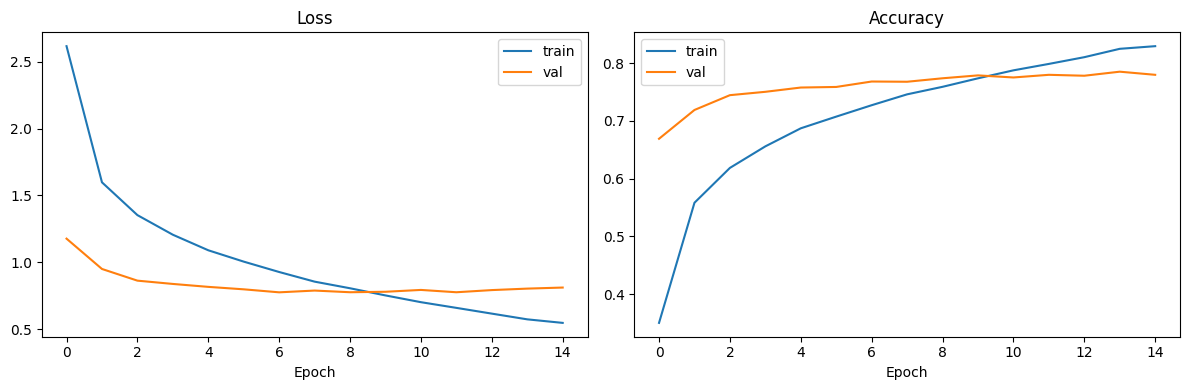

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()


# Define Fine-Grained Labels

In [16]:
FINE_LABELS = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]

assert len(FINE_LABELS) == 100


# Plot Confusion Matrix and Worst-20 F1

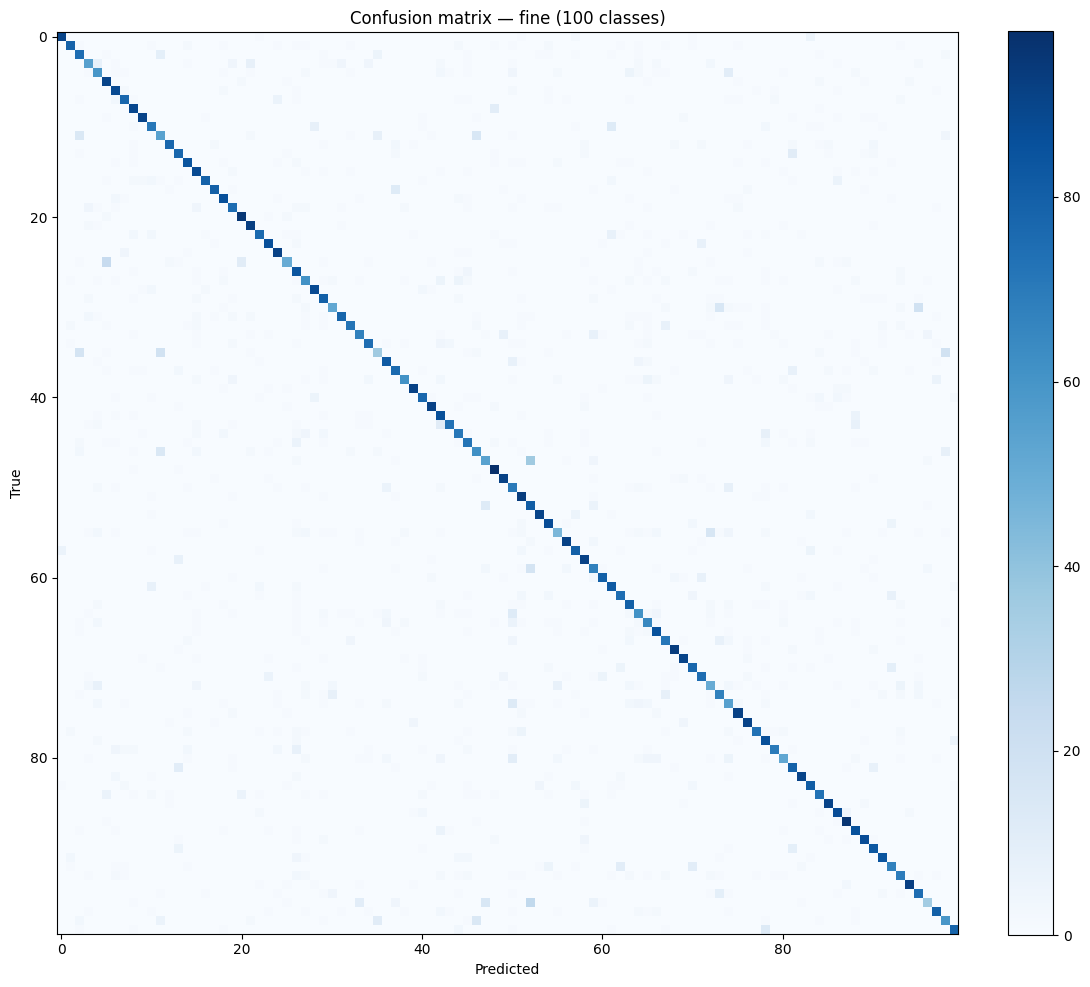

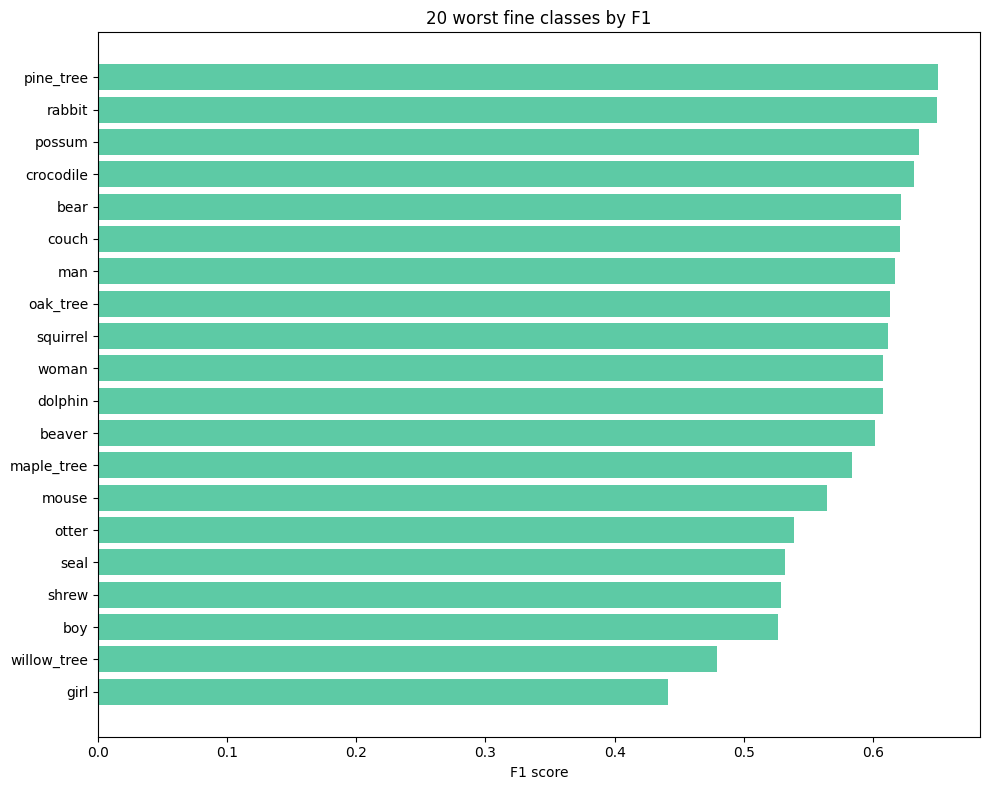

In [17]:
import numpy as np

cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — fine (100 classes)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

# %% ===== CELL 18: per-class F1 — show the 20 WORST classes (100 bars is unreadable) =====
diag = np.diag(cm)
col_sums = cm.sum(axis=0); row_sums = cm.sum(axis=1)
precision = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros_like(diag, float), where=(precision + recall) != 0)

worst = np.argsort(f1)[:20]   # 20 weakest classes
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(worst))
ax.barh(y, f1[worst], color="#5DCAA5")
ax.set_yticks(y); ax.set_yticklabels([FINE_LABELS[i] for i in worst])
ax.set_xlabel("F1 score"); ax.set_title("20 worst fine classes by F1")
plt.tight_layout()
plt.savefig(run_dir / "per_class_f1_worst20.png", dpi=150)
plt.show()

# Visualize Misclassified Examples for 10 Worst Classes

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step
'trout': 5 correct shown, 5 wrong shown (total 100, acc 84.00%)


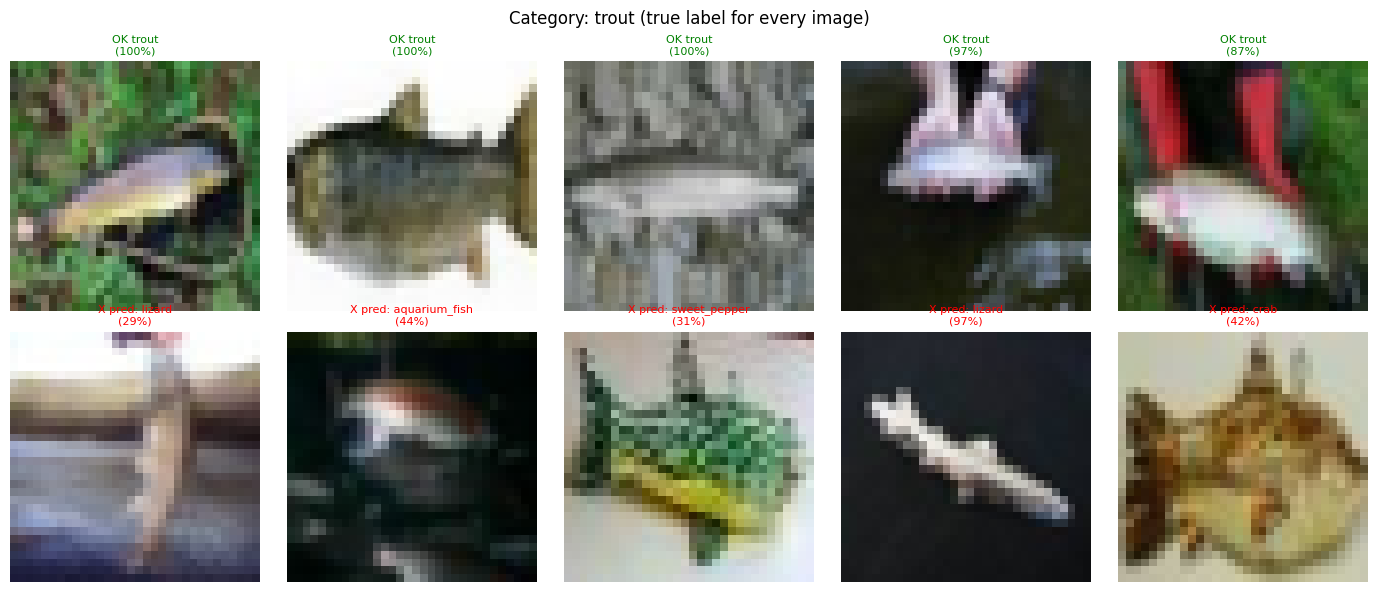

In [18]:
# Predict + per-category inspection.
test_labels = test_fine
test_images_normalized = test_images.astype(np.float32) / 255.0
probs = model.predict(test_images_normalized, batch_size=64, verbose=1)
preds = probs.argmax(axis=1)
confidences = probs.max(axis=1)

CATEGORY = "trout"  # change to any of the 100 fine class names
cat_id = FINE_LABELS.index(CATEGORY)

is_this_class = test_labels == cat_id
correct_idx = np.flatnonzero(is_this_class & (preds == cat_id))[:5]
wrong_idx = np.flatnonzero(is_this_class & (preds != cat_id))[:5]
print(
    f"'{CATEGORY}': {len(correct_idx)} correct shown, {len(wrong_idx)} wrong shown "
    f"(total {is_this_class.sum()}, acc {(preds[is_this_class] == cat_id).mean():.2%})"
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, idx in enumerate(correct_idx):
    axes[0, i].imshow(test_images[idx])
    axes[0, i].set_title(
        f"OK {FINE_LABELS[preds[idx]]}\n({confidences[idx]:.0%})",
        fontsize=8,
        color="green",
    )
    axes[0, i].axis("off")
for i, idx in enumerate(wrong_idx):
    axes[1, i].imshow(test_images[idx])
    axes[1, i].set_title(
        f"X pred: {FINE_LABELS[preds[idx]]}\n({confidences[idx]:.0%})",
        fontsize=8,
        color="red",
    )
    axes[1, i].axis("off")
fig.suptitle(f"Category: {CATEGORY} (true label for every image)", fontsize=12)
plt.tight_layout()
plt.savefig(Path(run_dir).parent / f"examples_{CATEGORY}.png", dpi=150)
plt.show()


# Set run_dir for Full Unfreeze

In [19]:
from pathlib import Path

run_dir = Path("/content/efnetb0_fine_ft")
if run_dir.exists():
    for item in sorted(run_dir.iterdir()):
        print(item)
else:
    print(f"{run_dir} is not present — run the training cell above first.")


/content/efnetb0_fine_ft/history.json
/content/efnetb0_fine_ft/metrics.json
/content/efnetb0_fine_ft/weights.weights.h5


# Load History and Metrics for Full Unfreeze

In [20]:
import json

with open(run_dir / "history.json") as f:
    history = json.load(f)
with open(run_dir / "metrics.json") as f:
    metrics = json.load(f)

print("History keys:", list(history.keys()))
print("=== Final test metrics (fine / 100 classes, FULL UNFREEZE) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

History keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
=== Final test metrics (fine / 100 classes, FULL UNFREEZE) ===
Accuracy:        0.7963
Macro precision: 0.8025
Macro recall:    0.7963
Macro F1:        0.7955
Weighted F1:     0.7955


# Display Metrics Summary Row for Full Unfreeze


In [21]:
summary_row = {
    "run_name": run_dir.name,
    "accuracy": metrics.get("accuracy"),
    "macro_f1": metrics.get("macro_f1"),
    "top_3_accuracy": metrics.get("top_3_accuracy"),
    "top_5_accuracy": metrics.get("top_5_accuracy"),
    "artifacts": str(run_dir),
}
print(json.dumps(summary_row, indent=2))


{
  "run_name": "efnetb0_fine_ft",
  "accuracy": 0.7962999939918518,
  "macro_f1": 0.7955221386381323,
  "top_3_accuracy": null,
  "top_5_accuracy": null,
  "artifacts": "/content/efnetb0_fine_ft"
}


# Plot Training Curves for Full Unfreeze

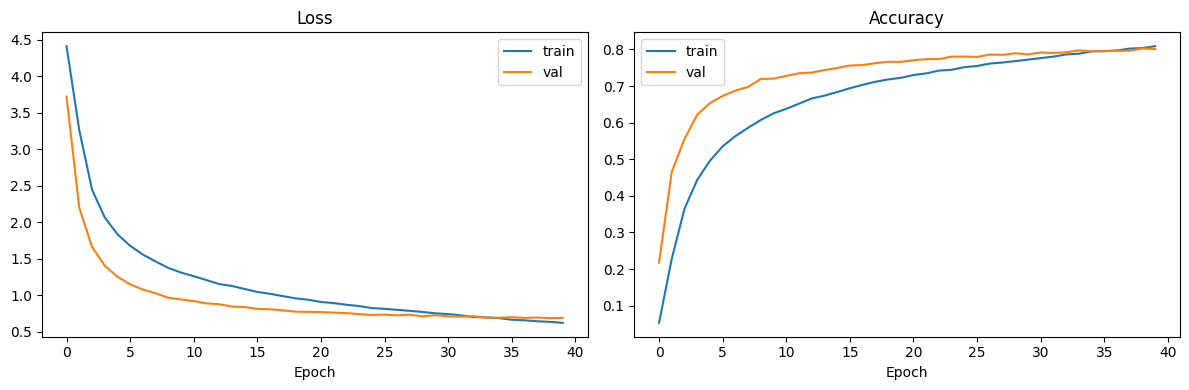

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()

# Define Fine-Grained Labels (Redundant)

In [23]:
FINE_LABELS = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]
assert len(FINE_LABELS) == 100

# Plot Confusion Matrix for Full Unfreeze

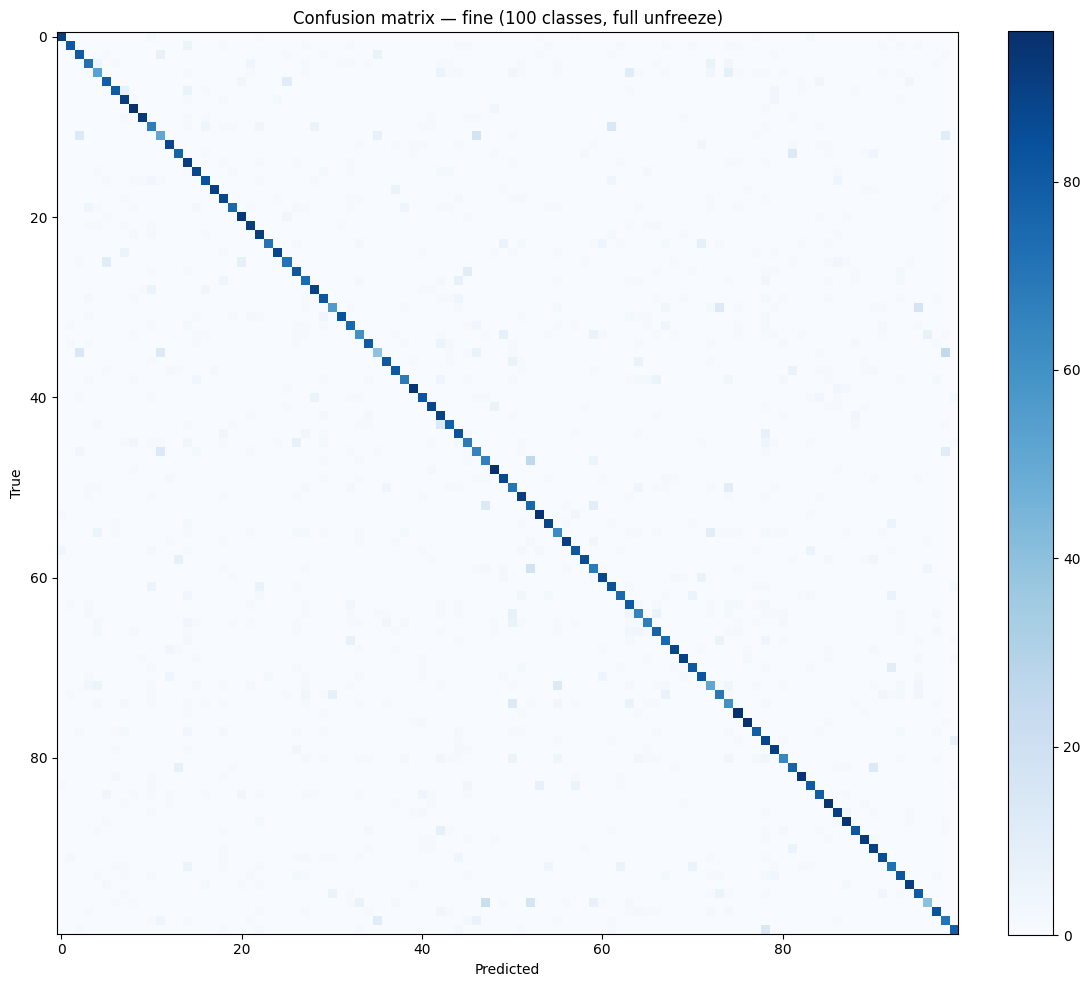

In [24]:
import numpy as np

cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — fine (100 classes, full unfreeze)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

# Load Data and Rebuild Model for Full Unfreeze Predictions

In [26]:
test_labels = test_fine
print(test_images.shape, test_labels.shape)

# Must match CONFIG C exactly: freeze_backbone=False, unfreeze_from="all", freeze_bn=True
model = build_efficientnet_b0(
    num_classes=100,
    freeze_backbone=False,
    unfreeze_from="all",
    freeze_bn=True,
    input_size=128,
)
model.load_weights(run_dir / "weights.weights.h5")

(10000, 32, 32, 3) (10000,)


# Plot Worst-10 F1 for Full Unfreeze

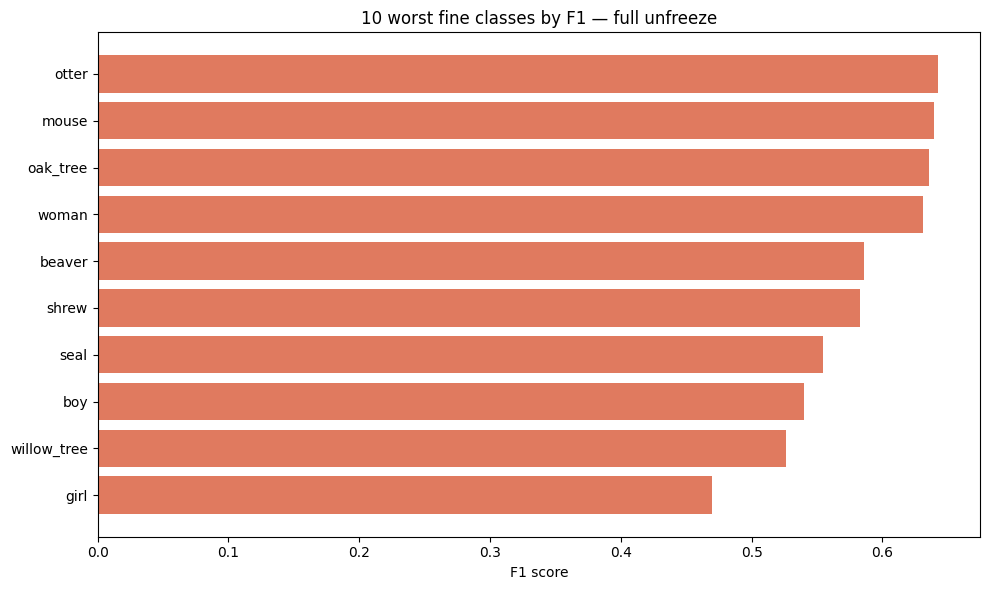

In [27]:
# %% ===== Worst-10 F1 plot — FULL UNFREEZE =====
run_dir_ft = Path("/content/efnetb0_fine_ft")

with open(run_dir_ft / "metrics.json") as f:
    metrics_ft = json.load(f)

cm_ft = np.array(metrics_ft["confusion_matrix"])

FINE_LABELS = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]

diag = np.diag(cm_ft)
col_sums = cm_ft.sum(axis=0); row_sums = cm_ft.sum(axis=1)
precision_ft = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall_ft    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1_ft = np.divide(2 * precision_ft * recall_ft, precision_ft + recall_ft,
                   out=np.zeros_like(diag, float), where=(precision_ft + recall_ft) != 0)

worst10_ft = np.argsort(f1_ft)[:10]   # 10 weakest classes for the full-unfreeze run

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(worst10_ft))
ax.barh(y, f1_ft[worst10_ft], color="#E07A5F")
ax.set_yticks(y); ax.set_yticklabels([FINE_LABELS[i] for i in worst10_ft])
ax.set_xlabel("F1 score"); ax.set_title("10 worst fine classes by F1 — full unfreeze")
plt.tight_layout()
plt.savefig(run_dir_ft / "per_class_f1_worst10.png", dpi=150)
plt.show()

# Plot Worst-10 Misclassified Examples Grid for Full Unfreeze

157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step


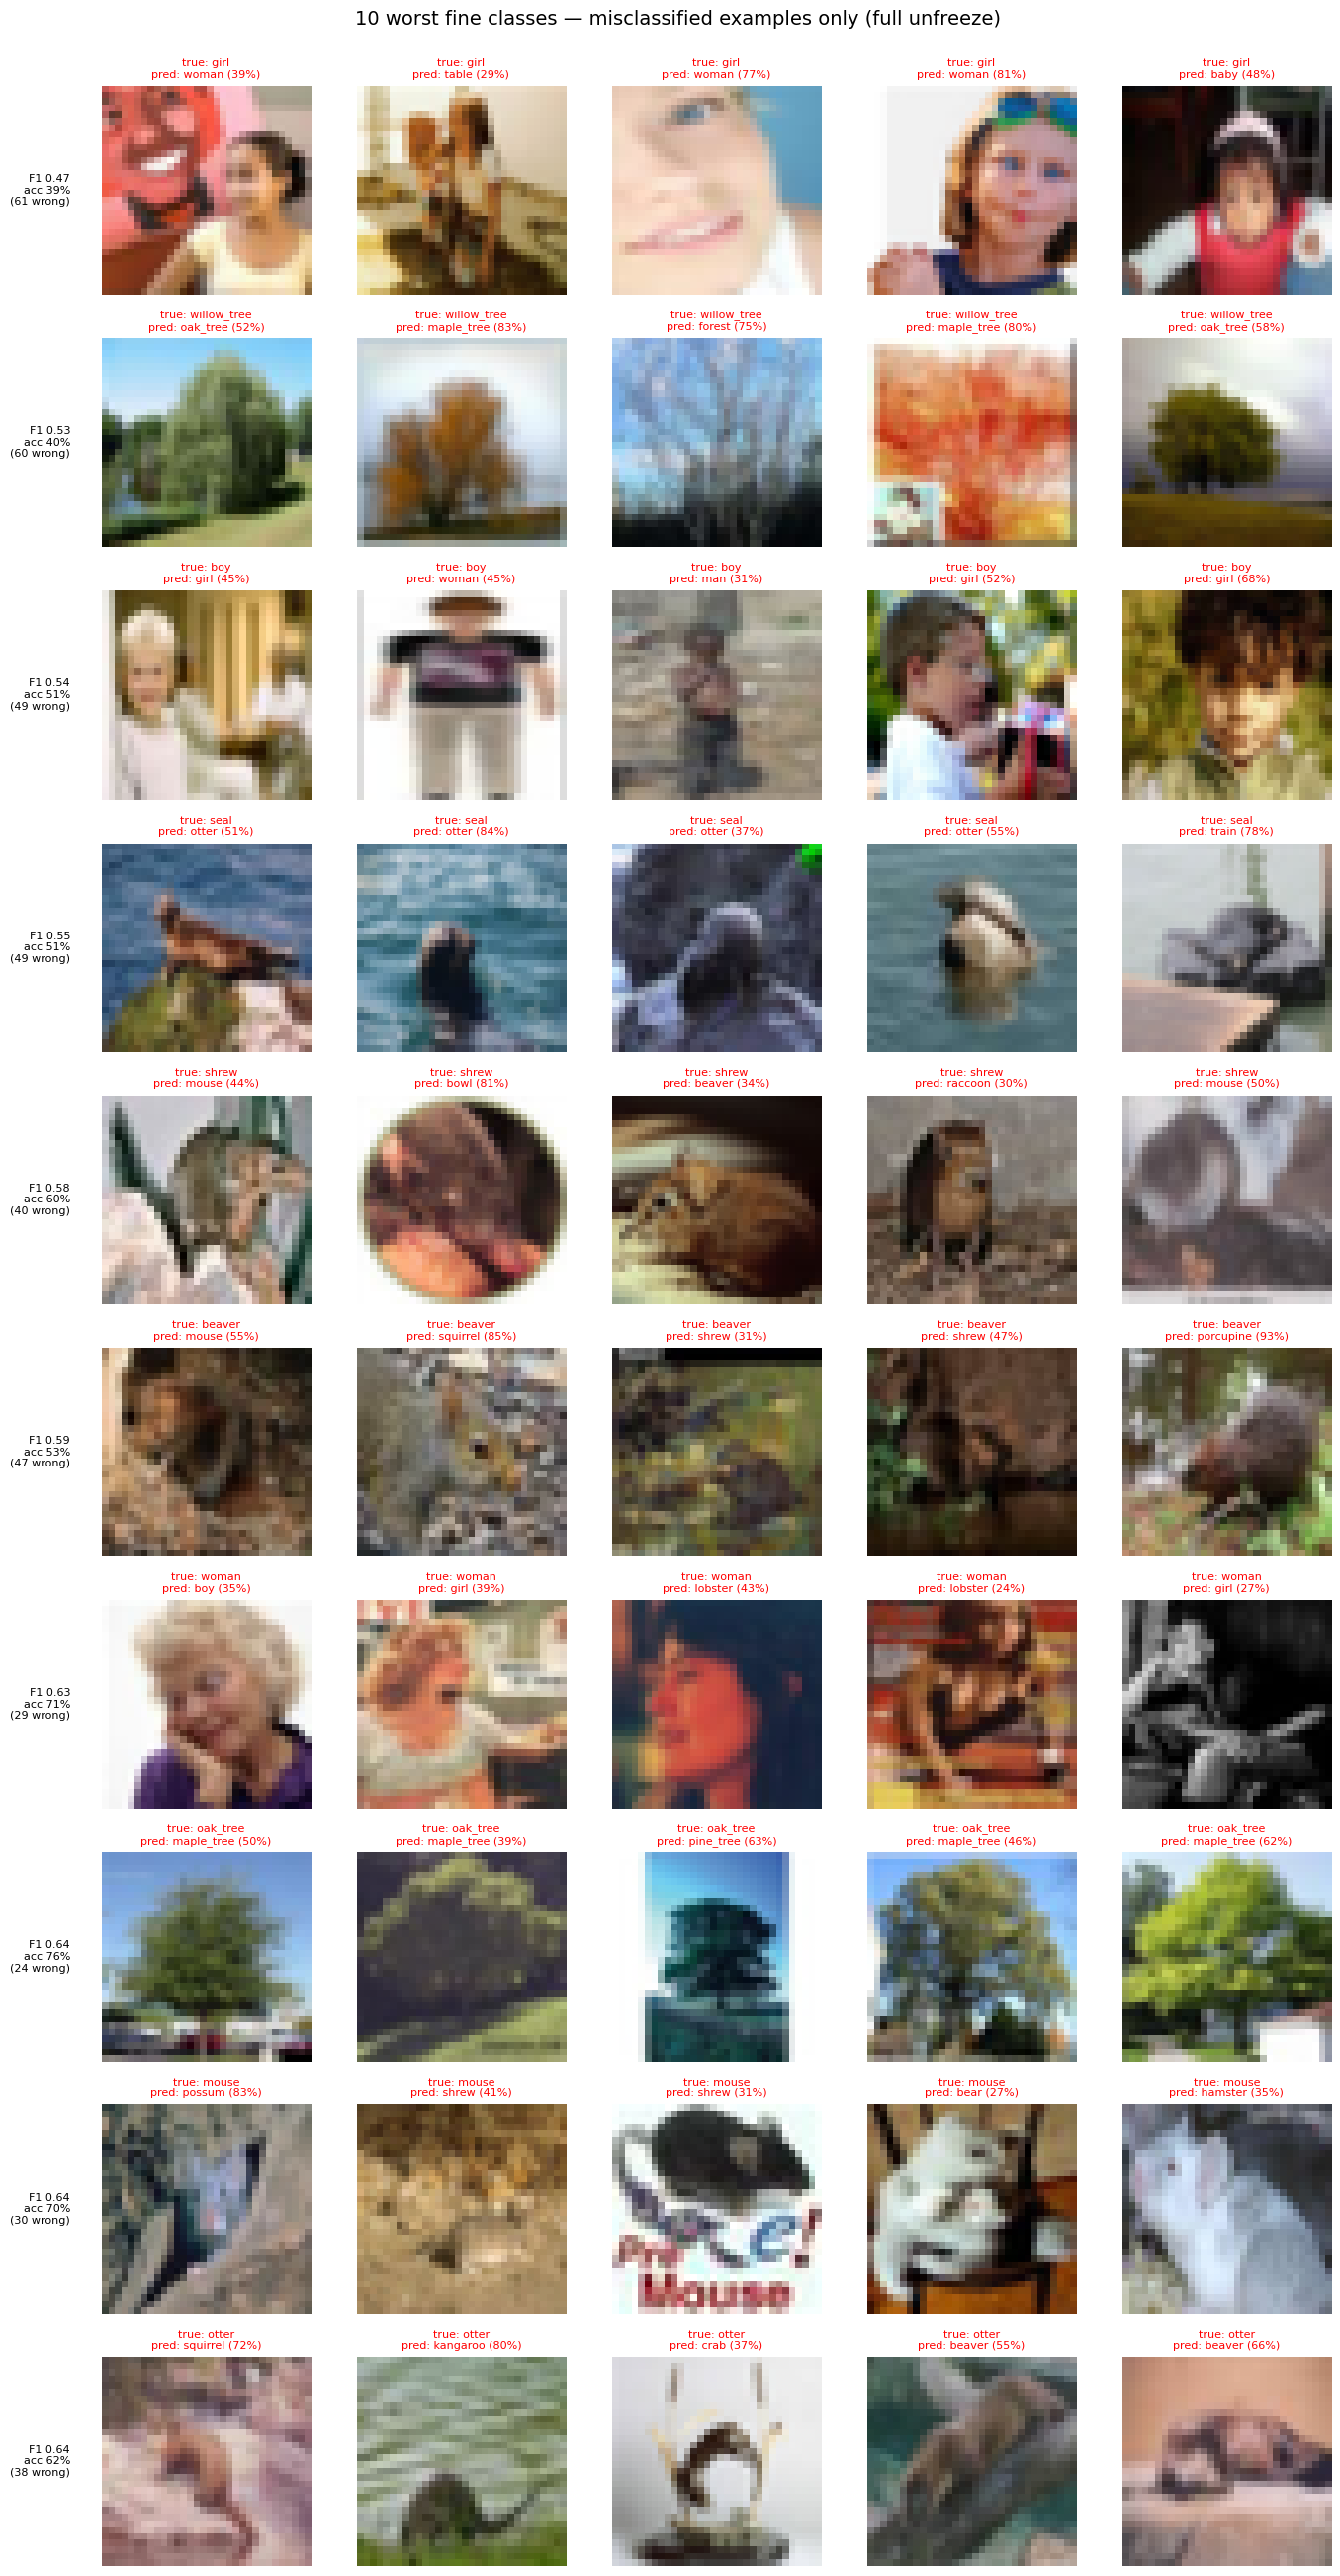

In [28]:
# %% ===== Worst-10 misclassified examples grid — FULL UNFREEZE =====
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

run_dir_ft = Path("/content/efnetb0_fine_ft")

with open(run_dir_ft / "metrics.json") as f:
    metrics_ft = json.load(f)

cm_ft = np.array(metrics_ft["confusion_matrix"])

diag = np.diag(cm_ft)
col_sums = cm_ft.sum(axis=0); row_sums = cm_ft.sum(axis=1)
precision_ft = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall_ft    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1_ft = np.divide(2 * precision_ft * recall_ft, precision_ft + recall_ft,
                   out=np.zeros_like(diag, float), where=(precision_ft + recall_ft) != 0)

worst_ft = np.argsort(f1_ft)[:10]

# Rebuild the full-unfreeze model and predict on the test set
test_labels = test_fine

model_ft = build_efficientnet_b0(
    num_classes=100,
    freeze_backbone=False,
    unfreeze_from="all",
    freeze_bn=True,
    input_size=128,
)
model_ft.load_weights(run_dir_ft / "weights.weights.h5")

test_images_normalized = test_images.astype(np.float32) / 255.0
probs_ft = model_ft.predict(test_images_normalized, batch_size=64, verbose=1)
preds_ft = probs_ft.argmax(axis=1)
confidences_ft = probs_ft.max(axis=1)

# Build the grid
fig, axes = plt.subplots(10, 5, figsize=(14, 26))

for row, cat_id in enumerate(worst_ft):
    category = FINE_LABELS[cat_id]
    is_this_class = test_labels == cat_id
    wrong_idx = np.flatnonzero(is_this_class & (preds_ft != cat_id))

    acc = (preds_ft[is_this_class] == cat_id).mean()
    n_wrong = len(wrong_idx)

    shown = wrong_idx[:5]
    for col in range(5):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(test_images[idx])
            ax.set_title(
                f"true: {category}\npred: {FINE_LABELS[preds_ft[idx]]} ({confidences_ft[idx]:.0%})",
                fontsize=8, color="red"
            )
        ax.axis("off")
        if col == 0:
            ax.text(-0.15, 0.5, f"F1 {f1_ft[cat_id]:.2f}\nacc {acc:.0%}\n({n_wrong} wrong)",
                     transform=ax.transAxes, fontsize=8, va="center", ha="right")

fig.suptitle("10 worst fine classes — misclassified examples only (full unfreeze)", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(run_dir_ft / "worst10_misclassified.png", dpi=150)
plt.show()